In [1]:
import astroquery
import astropy
import pandas as pd
import matplotlib

from astroquery.esa.euclid.core import Euclid

print("Astroquery:", astroquery.__version__)
print("Astropy:", astropy.__version__)
print("Pandas:", pd.__version__)
print("Euclid client: OK")
status = Euclid.get_status_messages()
print(status)

Astroquery: 0.4.11
Astropy: 8.0.1
Pandas: 2.3.3
Euclid client: OK
None


In [2]:
tables = Euclid.load_tables(
    only_names=True,
    include_shared_tables=False,
)

table_names = [
    table.get_qualified_name()
    for table in tables
]

relevant_names = [
    name
    for name in table_names
    if any(
        keyword in name.lower()
        for keyword in (
            "mer_catalogue",
            "mosaic_product",
            "phz",
            "spectra",
        )
    )
]

print("Number of public tables:", len(table_names))
print("Relevant Euclid Q1 tables:")

for name in relevant_names[:50]:
    print(name)

INFO: Retrieving tables... [astroquery.utils.tap.core]
INFO: Parsing tables... [astroquery.utils.tap.core]
INFO: Done. [astroquery.utils.tap.core]
Number of public tables: 102
Relevant Euclid Q1 tables:
catalogue.mer_catalogue
catalogue.phz_classification
catalogue.phz_galaxy_sed
catalogue.phz_nir_physical_parameters
catalogue.phz_photo_z
catalogue.phz_physical_parameters
catalogue.phz_qso_physical_parameters
catalogue.phz_star_sed
catalogue.phz_star_template
q1.combined_spectra
q1.combined_spectra_product
q1.mosaic_product
q1.phz_catalogue
q1.phz_catalogue_l3
q1.spectra_source
sedm.combined_spectra
sedm.combined_spectra_product
sedm.mosaic_product
sedm.phz_catalogue
sedm.phz_catalogue_l3
sedm.spectra_source


In [3]:
mer_table = next(
    name
    for name in table_names
    if name.lower().endswith(".mer_catalogue")
    or name.lower() == "mer_catalogue"
)

query = f"""
SELECT TOP 5
    object_id,
    right_ascension,
    declination,
    vis_det,
    det_quality_flag,
    flux_detection_total,
    flux_vis_sersic,
    segmentation_area,
    kron_radius
FROM {mer_table}
"""

print("Table:", mer_table)
print(query)

job = Euclid.launch_job_async(
    query,
    verbose=False,
)

catalog_preview = job.get_results()

print("Rows returned:", len(catalog_preview))
catalog_preview

Table: catalogue.mer_catalogue

SELECT TOP 5
    object_id,
    right_ascension,
    declination,
    vis_det,
    det_quality_flag,
    flux_detection_total,
    flux_vis_sersic,
    segmentation_area,
    kron_radius
FROM catalogue.mer_catalogue

INFO: Query finished. [astroquery.utils.tap.core]
Rows returned: 5


object_id,right_ascension,declination,vis_det,det_quality_flag,flux_detection_total,flux_vis_sersic,segmentation_area,kron_radius
int64,float64,float64,int64,int64,float64,float64,int64,float64
2749633020675612883,274.9633020096074,67.56128832993589,1,0,0.2743653655052185,0.26349034905433655,41,12.025489807128906
2749048526675614140,274.9048526615373,67.56141403607873,1,0,0.13477489352226257,0.16232235729694366,27,13.534197807312012
-636929289457747131,63.69292892487013,-45.774713171190136,1,0,0.4765916168689728,0.4436568319797516,63,13.433899879455566
-632726199457744946,63.27261995187014,-45.77449465537509,1,0,0.11101909726858139,0.1377057284116745,26,12.015092849731445
-632291690457744017,63.229169080989045,-45.77440178926634,1,0,2.2262487411499023,2.0609893798828125,227,26.987001419067383


In [4]:
target_name = "NGC 6505"
target_ra = 267.78
target_dec = 65.53
search_radius_deg = 1.0 / 60.0

query = f"""
SELECT TOP 100
    object_id,
    right_ascension,
    declination,
    vis_det,
    det_quality_flag,
    spurious_flag,
    point_like_prob,
    flux_vis_sersic,
    flux_y_sersic,
    flux_j_sersic,
    flux_h_sersic,
    segmentation_area,
    kron_radius,
    DISTANCE(
        {target_ra},
        {target_dec},
        right_ascension,
        declination
    ) AS distance_deg
FROM catalogue.mer_catalogue
WHERE DISTANCE(
    {target_ra},
    {target_dec},
    right_ascension,
    declination
) < {search_radius_deg}
ORDER BY distance_deg ASC
"""

print(query)

job = Euclid.launch_job_async(
    query,
    verbose=False,
)

ngc6505_sources = job.get_results()

print("Target:", target_name)
print("Search radius: 1 arcmin")
print("Sources returned:", len(ngc6505_sources))

ngc6505_sources[:10]


SELECT TOP 100
    object_id,
    right_ascension,
    declination,
    vis_det,
    det_quality_flag,
    spurious_flag,
    point_like_prob,
    flux_vis_sersic,
    flux_y_sersic,
    flux_j_sersic,
    flux_h_sersic,
    segmentation_area,
    kron_radius,
    DISTANCE(
        267.78,
        65.53,
        right_ascension,
        declination
    ) AS distance_deg
FROM catalogue.mer_catalogue
WHERE DISTANCE(
    267.78,
    65.53,
    right_ascension,
    declination
) < 0.016666666666666666
ORDER BY distance_deg ASC

INFO: Query finished. [astroquery.utils.tap.core]
Target: NGC 6505
Search radius: 1 arcmin
Sources returned: 100


object_id,right_ascension,declination,vis_det,det_quality_flag,spurious_flag,point_like_prob,flux_vis_sersic,flux_y_sersic,flux_j_sersic,flux_h_sersic,segmentation_area,kron_radius,distance_deg
int64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,int64,float64,float64
2677813028655307424,267.78130284070573,65.53074243100221,1,514,0,--,20957.607421875,20957.6171875,20957.607421875,20957.607421875,710965,1052.31640625,0.0009178380627363822
2677926210655368830,267.7926210570132,65.53688309633756,1,898,0,--,2355.930908203125,2351.635009765625,2351.697021484375,2351.659912109375,66589,314.3220520019531,0.008642930477984692
2677747417655202562,267.7747417649051,65.52025625411359,1,515,0,--,499.66265869140625,939.1681518554688,1107.5386962890625,1330.50390625,14874,155.3885040283203,0.009984300366126131
2677572845655247480,267.75728458224796,65.52474809804201,1,515,0,0.0,444.5340576171875,186.3064727783203,196.11026000976562,193.54624938964844,17846,348.4718933105469,0.010776436421295572
2677571104655235258,267.757110454316,65.52352585854318,1,512,1,0.00041141867404803634,3.2111597061157227,-2.402265787124634,2.443432331085205,0.7311752438545227,40,37.79208755493164,0.011481750788816
2677906637655192473,267.79066378231767,65.51924734945261,1,515,0,--,1211.317138671875,188.8394775390625,296.20916748046875,382.12493896484375,24888,597.798828125,0.01162490698432687
2677557167655232942,267.7557167721693,65.52329425724315,0,512,0,--,3.574049472808838,0.20579317212104797,0.9913313984870911,1.5647692680358887,19,20.447616577148438,0.012089946768089119
2677578728655379124,267.7578728323828,65.53791249009494,1,515,0,--,451.33856201171875,352.4634094238281,430.2464904785156,495.95025634765625,42125,416.7373962402344,0.012107326405945869
2677558907655228105,267.75589070336275,65.52281057155122,1,513,0,0.0002628132642712444,5.69826602935791,3.7082743644714355,8.059510231018066,5.773613452911377,113,45.355342864990234,0.012306300871558727


In [5]:
central_object_id = int(ngc6505_sources[0]["object_id"])

query = f"""
SELECT
    mer.object_id,
    mer.right_ascension,
    mer.declination,
    mer.det_quality_flag,
    mer.spurious_flag,
    cls.phz_star_prob,
    cls.phz_gal_prob,
    cls.phz_qso_prob,
    pz.phz_median
FROM catalogue.mer_catalogue AS mer
LEFT OUTER JOIN catalogue.phz_classification AS cls
    ON mer.object_id = cls.object_id
LEFT OUTER JOIN catalogue.phz_photo_z AS pz
    ON mer.object_id = pz.object_id
WHERE mer.object_id = {central_object_id}
"""

print("Central object ID:", central_object_id)
print(query)

job = Euclid.launch_job_async(query, verbose=False)
central_source_phz = job.get_results()

print("Rows returned:", len(central_source_phz))
central_source_phz

Central object ID: 2677813028655307424

SELECT
    mer.object_id,
    mer.right_ascension,
    mer.declination,
    mer.det_quality_flag,
    mer.spurious_flag,
    cls.phz_star_prob,
    cls.phz_gal_prob,
    cls.phz_qso_prob,
    pz.phz_median
FROM catalogue.mer_catalogue AS mer
LEFT OUTER JOIN catalogue.phz_classification AS cls
    ON mer.object_id = cls.object_id
LEFT OUTER JOIN catalogue.phz_photo_z AS pz
    ON mer.object_id = pz.object_id
WHERE mer.object_id = 2677813028655307424

INFO: Query finished. [astroquery.utils.tap.core]
Rows returned: 1


object_id,right_ascension,declination,det_quality_flag,spurious_flag,phz_star_prob,phz_gal_prob,phz_qso_prob,phz_median
int64,float64,float64,int64,int64,float64,float64,float64,float64
2677813028655307424,267.78130284070573,65.53074243100221,514,0,0.005495018791407347,0.36317768692970276,0.46085092425346375,0.05000000074505806


In [6]:
image_ra = float(ngc6505_sources[0]["right_ascension"])
image_dec = float(ngc6505_sources[0]["declination"])
image_search_radius_deg = 5.0 / 3600.0

mosaic_query = f"""
SELECT
    file_name,
    file_path,
    datalabs_path,
    instrument_name,
    filter_name,
    ra,
    dec,
    product_type,
    patch_id_list,
    tile_index,
    creation_date
FROM q1.mosaic_product
WHERE INTERSECTS(
    CIRCLE(
        {image_ra},
        {image_dec},
        {image_search_radius_deg}
    ),
    fov
) = 1
ORDER BY instrument_name, filter_name
"""

print("Image position:", image_ra, image_dec)
print("Search radius: 5 arcsec")

job = Euclid.launch_job_async(mosaic_query, verbose=False)
ngc6505_mosaics = job.get_results()

print("Mosaic products returned:", len(ngc6505_mosaics))
ngc6505_mosaics

Image position: 267.78130284070573 65.53074243100221
Search radius: 5 arcsec
INFO: Query finished. [astroquery.utils.tap.core]
Mosaic products returned: 9


file_name,file_path,datalabs_path,instrument_name,filter_name,ra,dec,product_type,patch_id_list,tile_index,creation_date
str88,str55,str43,str7,str11,float64,float64,str15,int64,int64,str23
EUC_MER_BGSUB-MOSAIC-PANSTARRS-I_TILE102158889-5BC663_20241024T203110.498476Z_00.00.fits,/euclid/repository_idr/iqr1/Q1_R1/MER/102158889/GPC,/data/euclid_q1/Q1_R1/MER/102158889/GPC,GPC,PANSTARRS_i,267.3807789,65.4983,DpdMerBksMosaic,--,102158889,2024-10-26T14:08:43.976
EUC_MER_BGSUB-MOSAIC-WISHES-G_TILE102158889-3DC3C3_20241024T205647.635112Z_00.00.fits,/euclid/repository_idr/iqr1/Q1_R1/MER/102158889/HSC,/data/euclid_q1/Q1_R1/MER/102158889/HSC,HSC,HSC_g,267.3807789,65.4983,DpdMerBksMosaic,--,102158889,2024-10-26T13:50:13.676
EUC_MER_BGSUB-MOSAIC-WISHES-Z_TILE102158889-60A7E6_20241024T204143.931276Z_00.00.fits,/euclid/repository_idr/iqr1/Q1_R1/MER/102158889/HSC,/data/euclid_q1/Q1_R1/MER/102158889/HSC,HSC,HSC_z,267.3807789,65.4983,DpdMerBksMosaic,--,102158889,2024-10-26T13:56:42.846
EUC_MER_BGSUB-MOSAIC-CFIS-R_TILE102158889-4366B7_20241024T203624.450577Z_00.00.fits,/euclid/repository_idr/iqr1/Q1_R1/MER/102158889/MEGACAM,/data/euclid_q1/Q1_R1/MER/102158889/MEGACAM,MEGACAM,MEGACAM_r,267.3807789,65.4983,DpdMerBksMosaic,--,102158889,2024-10-26T14:01:21.038
EUC_MER_BGSUB-MOSAIC-CFIS-U_TILE102158889-9E97F_20241024T204431.839748Z_00.00.fits,/euclid/repository_idr/iqr1/Q1_R1/MER/102158889/MEGACAM,/data/euclid_q1/Q1_R1/MER/102158889/MEGACAM,MEGACAM,MEGACAM_u,267.3807789,65.4983,DpdMerBksMosaic,--,102158889,2024-10-26T14:05:09.98
EUC_MER_BGSUB-MOSAIC-NIR-H_TILE102158889-ED035A_20241024T212936.705156Z_00.00.fits,/euclid/repository_idr/iqr1/Q1_R1/MER/102158889/NISP,/data/euclid_q1/Q1_R1/MER/102158889/NISP,NISP,NIR_H,267.3807789,65.4983,DpdMerBksMosaic,49,102158889,2024-10-26T13:10:32.453
EUC_MER_BGSUB-MOSAIC-NIR-J_TILE102158889-B8D44B_20241024T215040.579149Z_00.00.fits,/euclid/repository_idr/iqr1/Q1_R1/MER/102158889/NISP,/data/euclid_q1/Q1_R1/MER/102158889/NISP,NISP,NIR_J,267.3807789,65.4983,DpdMerBksMosaic,49,102158889,2024-10-26T13:24:14.889
EUC_MER_BGSUB-MOSAIC-NIR-Y_TILE102158889-AC6585_20241024T225321.344048Z_00.00.fits,/euclid/repository_idr/iqr1/Q1_R1/MER/102158889/NISP,/data/euclid_q1/Q1_R1/MER/102158889/NISP,NISP,NIR_Y,267.3807789,65.4983,DpdMerBksMosaic,49,102158889,2024-10-26T13:37:09.628
EUC_MER_BGSUB-MOSAIC-VIS_TILE102158889-F95D3B_20241025T024806.508980Z_00.00.fits,/euclid/repository_idr/iqr1/Q1_R1/MER/102158889/VIS,/data/euclid_q1/Q1_R1/MER/102158889/VIS,VIS,VIS,267.3807789,65.4983,DpdMerBksMosaic,49,102158889,2024-10-26T12:57:21.177


In [7]:
from pathlib import Path

import astropy.units as u
from astropy.coordinates import SkyCoord

vis_rows = ngc6505_mosaics[
    ngc6505_mosaics["instrument_name"] == "VIS"
]

if len(vis_rows) != 1:
    raise ValueError(f"Expected one VIS mosaic, found {len(vis_rows)}")

vis_row = vis_rows[0]

vis_server_path = (
    f"{str(vis_row['file_path']).rstrip('/')}/"
    f"{str(vis_row['file_name'])}"
)

target_coord = SkyCoord(
    ra=image_ra * u.deg,
    dec=image_dec * u.deg,
    frame="icrs",
)

cutout_directory = Path(
    r"D:\AST\07_Euclid_Q1_Case_Study\data\cutouts"
)
vis_output_path = (
    cutout_directory / "NGC6505_VIS_r0p1arcmin.fits"
)

print("VIS product:", vis_row["file_name"])
print("Tile index:", vis_row["tile_index"])
print("Server path:", vis_server_path)
print("Local output:", vis_output_path)
print("Cutout radius: 0.1 arcmin = 6 arcsec")

if vis_output_path.exists():
    print("The cutout already exists; download skipped.")
    vis_cutout_files = [str(vis_output_path)]
else:
    vis_cutout_files = Euclid.get_cutout(
        file_path=vis_server_path,
        instrument="VIS",
        id=str(vis_row["tile_index"]),
        coordinate=target_coord,
        radius=0.1 * u.arcmin,
        output_file=str(vis_output_path),
        verbose=True,
    )

print("Returned files:", vis_cutout_files)

VIS product: EUC_MER_BGSUB-MOSAIC-VIS_TILE102158889-F95D3B_20241025T024806.508980Z_00.00.fits
Tile index: 102158889
Server path: /euclid/repository_idr/iqr1/Q1_R1/MER/102158889/VIS/EUC_MER_BGSUB-MOSAIC-VIS_TILE102158889-F95D3B_20241025T024806.508980Z_00.00.fits
Local output: D:\AST\07_Euclid_Q1_Case_Study\data\cutouts\NGC6505_VIS_r0p1arcmin.fits
Cutout radius: 0.1 arcmin = 6 arcsec
Retrieving data.
Data request: TAPCLIENT=ASTROQUERY&FILEPATH=%2Feuclid%2Frepository_idr%2Fiqr1%2FQ1_R1%2FMER%2F102158889%2FVIS%2FEUC_MER_BGSUB-MOSAIC-VIS_TILE102158889-F95D3B_20241025T024806.508980Z_00.00.fits&COLLECTION=VIS&OBSID=102158889&POS=CIRCLE%2C267.7813031811303%2C65.53074785677605%2C0.0016666666666666668
------>https
host = eas.esac.esa.int:443
context = /sas-cutout/cutout
Content-type = application/x-www-form-urlencoded
200 
Reading...
Done.
Returned files: ['D:\\AST\\07_Euclid_Q1_Case_Study\\data\\cutouts\\NGC6505_VIS_r0p1arcmin.fits']


In [8]:
from pathlib import Path

import numpy as np
from astropy.io import fits

vis_cutout_path = Path(vis_cutout_files[0])

print("FITS file:", vis_cutout_path)
print("File exists:", vis_cutout_path.exists())
print("File size (MB):", round(vis_cutout_path.stat().st_size / 1024**2, 2))

with fits.open(vis_cutout_path, memmap=True) as hdul:
    print("\nHDU structure:")
    hdul.info()

    image_data = hdul[0].data
    header = hdul[0].header

    print("\nImage information:")
    print("Shape:", image_data.shape)
    print("Data type:", image_data.dtype)
    print("Finite fraction:", np.isfinite(image_data).mean())

    finite_pixels = image_data[np.isfinite(image_data)]

    print("Minimum:", np.min(finite_pixels))
    print("Median:", np.median(finite_pixels))
    print("Maximum:", np.max(finite_pixels))

    print("\nSelected FITS header values:")
    for keyword in [
        "BUNIT",
        "TELESCOP",
        "INSTRUME",
        "FILTER",
        "NAXIS1",
        "NAXIS2",
        "CRVAL1",
        "CRVAL2",
        "CTYPE1",
        "CTYPE2",
    ]:
        print(f"{keyword}: {header.get(keyword, 'Not present')}")

FITS file: D:\AST\07_Euclid_Q1_Case_Study\data\cutouts\NGC6505_VIS_r0p1arcmin.fits
File exists: True
File size (MB): 0.06

HDU structure:
Filename: D:\AST\07_Euclid_Q1_Case_Study\data\cutouts\NGC6505_VIS_r0p1arcmin.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  None          1 PrimaryHDU      50   (122, 122)   float32   

Image information:
Shape: (122, 122)
Data type: >f4
Finite fraction: 1.0
Minimum: 0.19188704
Median: 0.56000096
Maximum: 19.00433

Selected FITS header values:
BUNIT: Not present
TELESCOP: Not present
INSTRUME: Not present
FILTER: VIS
NAXIS1: 122
NAXIS2: 122
CRVAL1: 267.3807789
CRVAL2: 65.4983
CTYPE1: RA---TAN
CTYPE2: DEC--TAN


Pixel scale (arcsec/pixel): [0.1 0.1]
Target pixel position: 60.66 59.93
Image center: 60.5 60.5


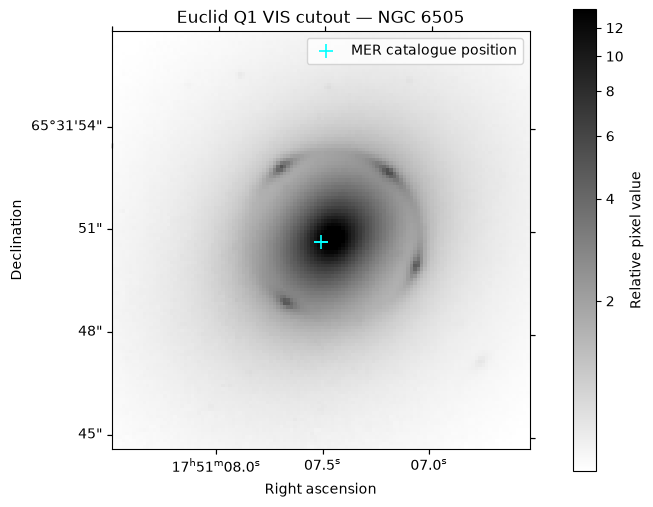

In [9]:
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import (
    AsinhStretch,
    ImageNormalize,
    PercentileInterval,
)
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales

with fits.open(vis_cutout_path, memmap=True) as hdul:
    vis_image = hdul[0].data.astype(float, copy=True)
    vis_header = hdul[0].header.copy()

vis_wcs = WCS(vis_header)

pixel_scales_arcsec = (
    proj_plane_pixel_scales(vis_wcs) * 3600.0
)
target_x, target_y = vis_wcs.world_to_pixel(target_coord)

print(
    "Pixel scale (arcsec/pixel):",
    pixel_scales_arcsec,
)
print(
    "Target pixel position:",
    round(float(target_x), 2),
    round(float(target_y), 2),
)
print(
    "Image center:",
    (vis_image.shape[1] - 1) / 2,
    (vis_image.shape[0] - 1) / 2,
)

normalization = ImageNormalize(
    vis_image,
    interval=PercentileInterval(99.5),
    stretch=AsinhStretch(),
)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection=vis_wcs)

image_artist = ax.imshow(
    vis_image,
    origin="lower",
    cmap="gray_r",
    norm=normalization,
)

ax.scatter(
    image_ra,
    image_dec,
    transform=ax.get_transform("world"),
    marker="+",
    s=100,
    linewidths=1.2,
    color="cyan",
    label="MER catalogue position",
)

ax.coords[0].set_axislabel("Right ascension")
ax.coords[1].set_axislabel("Declination")
ax.set_title("Euclid Q1 VIS cutout — NGC 6505")
ax.legend(loc="upper right")

colorbar = fig.colorbar(
    image_artist,
    ax=ax,
    pad=0.08,
)
colorbar.set_label("Relative pixel value")

plt.show()

Published Einstein radius: 2.5 arcsec
Einstein radius in this image: 24.999999999998 pixels


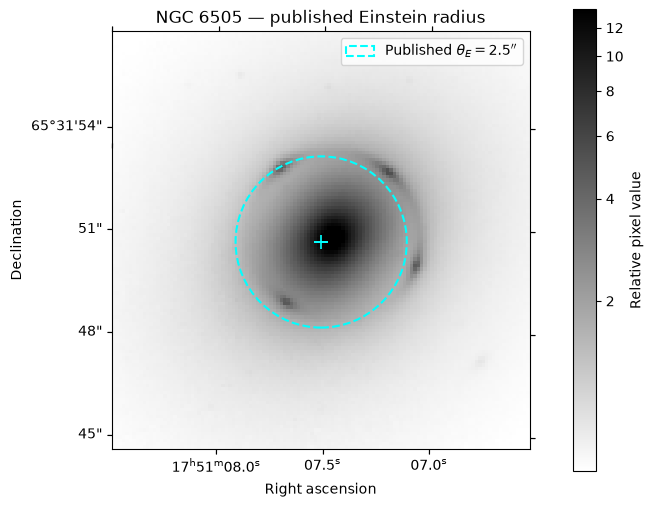

In [10]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from astropy.visualization import (
    AsinhStretch,
    ImageNormalize,
    PercentileInterval,
)

einstein_radius_arcsec = 2.5
mean_pixel_scale = float(pixel_scales_arcsec.mean())
einstein_radius_pixels = (
    einstein_radius_arcsec / mean_pixel_scale
)

print("Published Einstein radius:", einstein_radius_arcsec, "arcsec")
print("Einstein radius in this image:", einstein_radius_pixels, "pixels")

normalization = ImageNormalize(
    vis_image,
    interval=PercentileInterval(99.5),
    stretch=AsinhStretch(),
)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection=vis_wcs)

image_artist = ax.imshow(
    vis_image,
    origin="lower",
    cmap="gray_r",
    norm=normalization,
)

ring_overlay = Circle(
    (target_x, target_y),
    radius=einstein_radius_pixels,
    facecolor="none",
    edgecolor="cyan",
    linewidth=1.5,
    linestyle="--",
    label=r"Published $\theta_E = 2.5''$",
)
ax.add_patch(ring_overlay)

ax.plot(
    target_x,
    target_y,
    marker="+",
    markersize=10,
    markeredgewidth=1.2,
    color="cyan",
)

ax.coords[0].set_axislabel("Right ascension")
ax.coords[1].set_axislabel("Declination")
ax.set_title("NGC 6505 — published Einstein radius")
ax.legend(loc="upper right")

colorbar = fig.colorbar(
    image_artist,
    ax=ax,
    pad=0.08,
)
colorbar.set_label("Relative pixel value")

plt.show()

Smoothing sigma: 8.0 pixels
Smoothing scale: 0.8 arcsec
Residual display limit: 1.5115930572971934


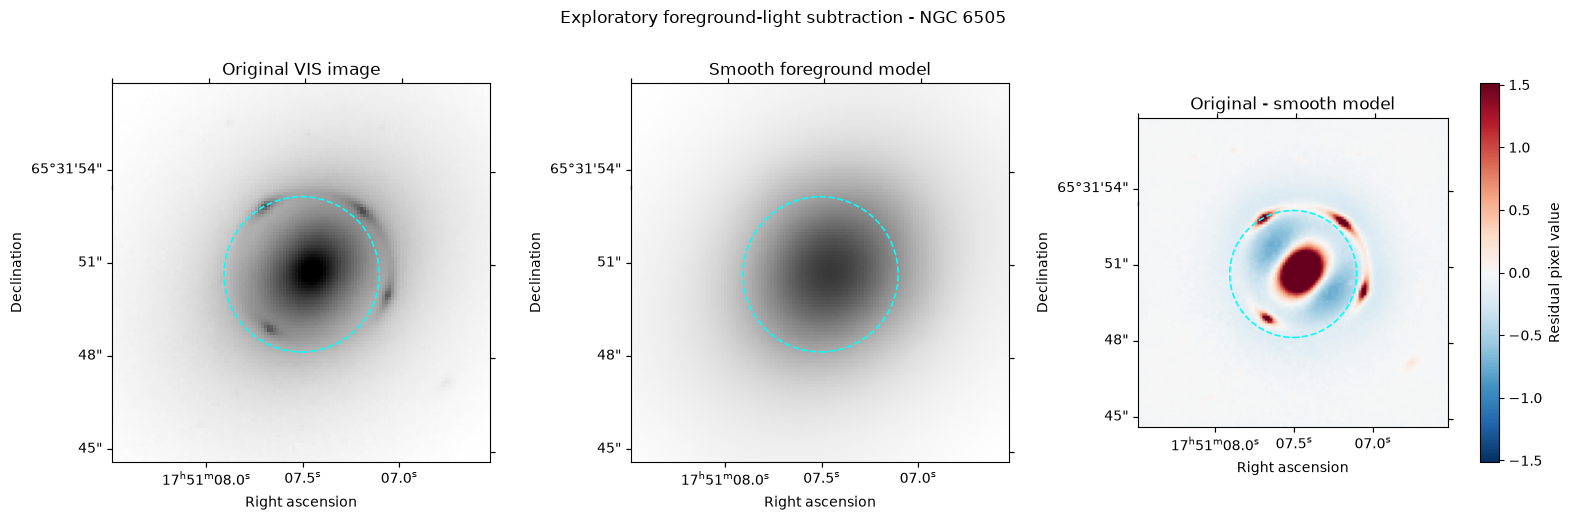

In [11]:
from astropy.convolution import Gaussian2DKernel, convolve

smoothing_sigma_pixels = 8.0

galaxy_kernel = Gaussian2DKernel(
    x_stddev=smoothing_sigma_pixels
)

smooth_galaxy_model = convolve(
    vis_image,
    galaxy_kernel,
    boundary="extend",
    normalize_kernel=True,
)

vis_residual = vis_image - smooth_galaxy_model

y_grid, x_grid = np.indices(vis_image.shape)

radius_grid = np.hypot(
    x_grid - target_x,
    y_grid - target_y,
)

scale_region = (
    (radius_grid > 8)
    & (radius_grid < 50)
    & np.isfinite(vis_residual)
)

residual_limit = np.percentile(
    np.abs(vis_residual[scale_region]),
    99.0,
)

print("Smoothing sigma:", smoothing_sigma_pixels, "pixels")
print(
    "Smoothing scale:",
    round(smoothing_sigma_pixels * mean_pixel_scale, 2),
    "arcsec",
)
print("Residual display limit:", residual_limit)

fig = plt.figure(figsize=(16, 5))

panels = [
    (
        vis_image,
        "Original VIS image",
        {
            "cmap": "gray_r",
            "norm": normalization,
        },
    ),
    (
        smooth_galaxy_model,
        "Smooth foreground model",
        {
            "cmap": "gray_r",
            "norm": normalization,
        },
    ),
    (
        vis_residual,
        "Original - smooth model",
        {
            "cmap": "RdBu_r",
            "vmin": -residual_limit,
            "vmax": residual_limit,
        },
    ),
]

axes = []
residual_artist = None

for index, (data, title, image_options) in enumerate(panels):
    ax = fig.add_subplot(
        1,
        3,
        index + 1,
        projection=vis_wcs,
    )

    artist = ax.imshow(
        data,
        origin="lower",
        **image_options,
    )

    ring = Circle(
        (target_x, target_y),
        radius=einstein_radius_pixels,
        facecolor="none",
        edgecolor="cyan",
        linewidth=1.2,
        linestyle="--",
    )
    ax.add_patch(ring)

    ax.set_title(title)
    ax.coords[0].set_axislabel("Right ascension")
    ax.coords[1].set_axislabel("Declination")

    axes.append(ax)

    if index == 2:
        residual_artist = artist

fig.colorbar(
    residual_artist,
    ax=axes[2],
    pad=0.08,
    label="Residual pixel value",
)

fig.suptitle(
    "Exploratory foreground-light subtraction - NGC 6505",
    y=1.03,
)

plt.tight_layout()
plt.show()

In [12]:
nir_filter_order = [
    "NIR_Y",
    "NIR_J",
    "NIR_H",
]

nir_cutout_paths = {}

for filter_name in nir_filter_order:
    matching_rows = ngc6505_mosaics[
        ngc6505_mosaics["filter_name"] == filter_name
    ]

    if len(matching_rows) != 1:
        raise ValueError(
            f"Expected one {filter_name} mosaic, "
            f"found {len(matching_rows)}"
        )

    row = matching_rows[0]

    server_path = (
        f"{str(row['file_path']).rstrip('/')}/"
        f"{str(row['file_name'])}"
    )

    output_path = (
        cutout_directory
        / f"NGC6505_{filter_name}_r0p1arcmin.fits"
    )

    print(f"\nProcessing {filter_name}")
    print("Server product:", row["file_name"])
    print("Local output:", output_path)

    if output_path.exists():
        print("File already exists; download skipped.")
        returned_files = [str(output_path)]
    else:
        returned_files = Euclid.get_cutout(
            file_path=server_path,
            instrument="NISP",
            id=str(row["tile_index"]),
            coordinate=target_coord,
            radius=0.1 * u.arcmin,
            output_file=str(output_path),
            verbose=True,
        )

    if not returned_files:
        raise RuntimeError(
            f"No cutout was returned for {filter_name}"
        )

    nir_cutout_paths[filter_name] = Path(
        returned_files[0]
    )

print("\nDownloaded NIR cutouts:")
for filter_name, path in nir_cutout_paths.items():
    print(
        filter_name,
        "->",
        path,
        f"({path.stat().st_size / 1024**2:.3f} MB)",
    )


Processing NIR_Y
Server product: EUC_MER_BGSUB-MOSAIC-NIR-Y_TILE102158889-AC6585_20241024T225321.344048Z_00.00.fits
Local output: D:\AST\07_Euclid_Q1_Case_Study\data\cutouts\NGC6505_NIR_Y_r0p1arcmin.fits
Retrieving data.
Data request: TAPCLIENT=ASTROQUERY&FILEPATH=%2Feuclid%2Frepository_idr%2Fiqr1%2FQ1_R1%2FMER%2F102158889%2FNISP%2FEUC_MER_BGSUB-MOSAIC-NIR-Y_TILE102158889-AC6585_20241024T225321.344048Z_00.00.fits&COLLECTION=NISP&OBSID=102158889&POS=CIRCLE%2C267.7813031811303%2C65.53074785677605%2C0.0016666666666666668
------>https
host = eas.esac.esa.int:443
context = /sas-cutout/cutout
Content-type = application/x-www-form-urlencoded
200 
Reading...
Done.

Processing NIR_J
Server product: EUC_MER_BGSUB-MOSAIC-NIR-J_TILE102158889-B8D44B_20241024T215040.579149Z_00.00.fits
Local output: D:\AST\07_Euclid_Q1_Case_Study\data\cutouts\NGC6505_NIR_J_r0p1arcmin.fits
Retrieving data.
Data request: TAPCLIENT=ASTROQUERY&FILEPATH=%2Feuclid%2Frepository_idr%2Fiqr1%2FQ1_R1%2FMER%2F102158889%2FNISP%2

Multiband image information:
VIS | shape: (122, 122) | pixel scale: 0.1 arcsec/pixel | median: 0.56 | maximum: 19.00433
NIR_Y | shape: (122, 122) | pixel scale: 0.1 arcsec/pixel | median: 148.56678 | maximum: 4608.25537
NIR_J | shape: (122, 122) | pixel scale: 0.1 arcsec/pixel | median: 204.74249 | maximum: 6867.69238
NIR_H | shape: (122, 122) | pixel scale: 0.1 arcsec/pixel | median: 249.3569 | maximum: 7432.00146


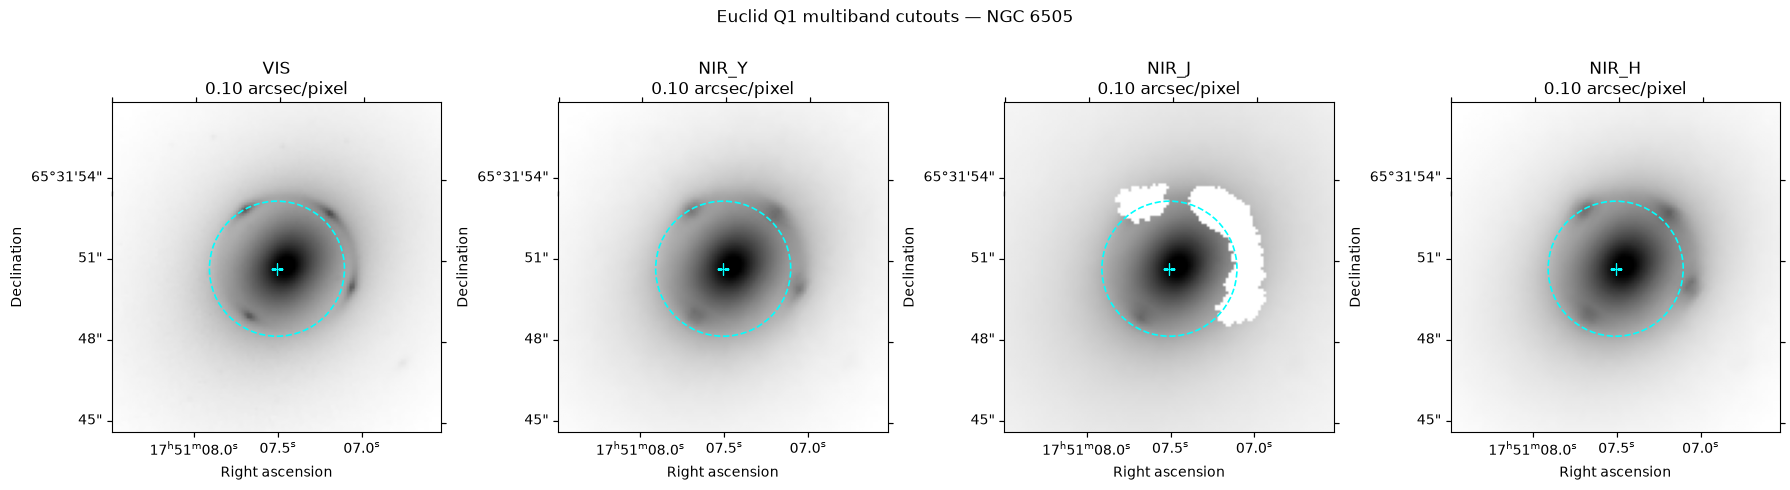

In [13]:
multiband_images = {
    "VIS": {
        "data": vis_image,
        "wcs": vis_wcs,
        "path": vis_cutout_path,
    }
}

for filter_name, path in nir_cutout_paths.items():
    with fits.open(path, memmap=True) as hdul:
        multiband_images[filter_name] = {
            "data": hdul[0].data.astype(float, copy=True),
            "wcs": WCS(hdul[0].header),
            "path": path,
        }

display_order = [
    "VIS",
    "NIR_Y",
    "NIR_J",
    "NIR_H",
]

print("Multiband image information:")

for band_name in display_order:
    band = multiband_images[band_name]
    band_data = band["data"]
    band_wcs = band["wcs"]

    band_pixel_scale = float(
        proj_plane_pixel_scales(band_wcs).mean()
        * 3600.0
    )

    print(
        band_name,
        "| shape:",
        band_data.shape,
        "| pixel scale:",
        round(band_pixel_scale, 3),
        "arcsec/pixel",
        "| median:",
        round(float(np.nanmedian(band_data)), 5),
        "| maximum:",
        round(float(np.nanmax(band_data)), 5),
    )

fig = plt.figure(figsize=(18, 5))

for index, band_name in enumerate(display_order):
    band = multiband_images[band_name]
    band_data = band["data"]
    band_wcs = band["wcs"]

    band_pixel_scale = float(
        proj_plane_pixel_scales(band_wcs).mean()
        * 3600.0
    )

    band_target_x, band_target_y = (
        band_wcs.world_to_pixel(target_coord)
    )

    band_einstein_radius_pixels = (
        einstein_radius_arcsec / band_pixel_scale
    )

    band_normalization = ImageNormalize(
        band_data,
        interval=PercentileInterval(99.5),
        stretch=AsinhStretch(),
    )

    ax = fig.add_subplot(
        1,
        4,
        index + 1,
        projection=band_wcs,
    )

    ax.imshow(
        band_data,
        origin="lower",
        cmap="gray_r",
        norm=band_normalization,
    )

    ring = Circle(
        (band_target_x, band_target_y),
        radius=band_einstein_radius_pixels,
        facecolor="none",
        edgecolor="cyan",
        linewidth=1.2,
        linestyle="--",
    )
    ax.add_patch(ring)

    ax.plot(band_target_x, band_target_y, marker="+", markersize=8, markeredgewidth=1.0, color="cyan",)

    ax.set_title(
        f"{band_name}\n"
        f"{band_pixel_scale:.2f} arcsec/pixel"
    )
    ax.coords[0].set_axislabel("Right ascension")
    ax.coords[1].set_axislabel("Declination")

fig.suptitle(
    "Euclid Q1 multiband cutouts — NGC 6505",
    y=1.03,
)

plt.tight_layout()
plt.show()

In [14]:
figure_output_path = Path(
    r"D:\AST\07_Euclid_Q1_Case_Study"
    r"\outputs\figures\ngc6505_multiband.png"
)

sources_output_path = Path(
    r"D:\AST\07_Euclid_Q1_Case_Study"
    r"\outputs\tables\ngc6505_sources_1arcmin.csv"
)

products_output_path = Path(
    r"D:\AST\07_Euclid_Q1_Case_Study"
    r"\outputs\tables\ngc6505_mosaic_products.csv"
)

fig.savefig(
    figure_output_path,
    dpi=300,
    bbox_inches="tight",
)

ngc6505_sources.to_pandas().to_csv(
    sources_output_path,
    index=False,
)

ngc6505_mosaics.to_pandas().to_csv(
    products_output_path,
    index=False,
)

print("Saved figure:", figure_output_path)
print("Saved source catalogue:", sources_output_path)
print("Saved product metadata:", products_output_path)

Saved figure: D:\AST\07_Euclid_Q1_Case_Study\outputs\figures\ngc6505_multiband.png
Saved source catalogue: D:\AST\07_Euclid_Q1_Case_Study\outputs\tables\ngc6505_sources_1arcmin.csv
Saved product metadata: D:\AST\07_Euclid_Q1_Case_Study\outputs\tables\ngc6505_mosaic_products.csv
